In [ ]:
import pandas as pd
import glob, os
import matplotlib.pyplot as plt
import numpy as np
import scipy.interpolate as interp1d

In [ ]:
Ns = [2, 20, 200, 2000, 20000]
means, memory = [], []

for N in Ns:
    base_dir = f"/users/ebrown62/scCODA/sccoda/datasets/results/N={N}"
    csv_files = glob.glob(os.path.join(base_dir, "*/profiling_*.csv"))
    time_vals, mem_vals = [], []
    for f in csv_files:
        df = pd.read_csv(f)
        time_vals.append(df["elapsed_time_seconds"].mean())
        mem_vals.append(df["peak_memory_MB"].mean())

    mean_time = float(round(sum(time_vals) / len(time_vals), 4))
    mean_mem = float(round(sum(mem_vals) / len(mem_vals), 4))
    means.append(mean_time)
    memory.append(mean_mem)


Ns: [2, 20, 200, 2000, 20000]
Mean times (s): [56.676, 64.5202, 131.2849, 671.3821, 5310.5523]
Mean memory (MB): [38.3348, 54.9487, 170.1598, 1322.2918, 12843.4358]


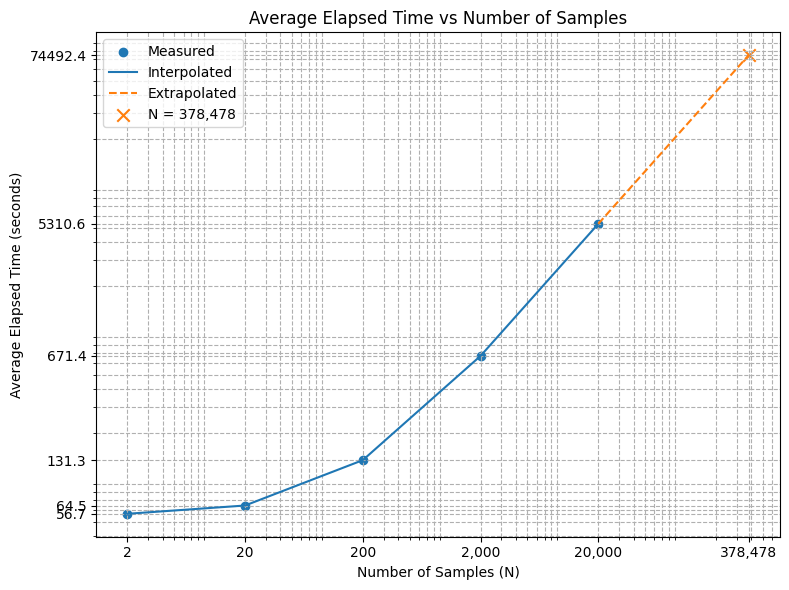

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def plot_times(Ns, means, N_extrap=378478):
    Ns = np.asarray(Ns, dtype=float)
    means = np.asarray(means, dtype=float)

    # sort just in case
    order = np.argsort(Ns)
    Ns = Ns[order]
    means = means[order]
    logN = np.log10(Ns)
    logT = np.log10(means)

    f_log = interp1d(
        logN,
        logT,
        kind="linear", 
        fill_value="extrapolate"
    )
    logN_last = logN[-1]
    logN_extrap = np.log10(N_extrap)
    logN_solid = np.linspace(logN[0], logN_last, 300)
    logT_solid = f_log(logN_solid)
    Ns_solid = 10 ** logN_solid
    means_solid = 10 ** logT_solid
    logN_dash = np.linspace(logN_last, logN_extrap, 100)
    logT_dash = f_log(logN_dash)
    Ns_dash = 10 ** logN_dash
    means_dash = 10 ** logT_dash

    T_extrap = means_dash[-1]
    plt.figure(figsize=(8, 6))


    plt.scatter(Ns, means, marker='o', label='Measured')
    plt.plot(Ns_solid, means_solid, '-', label='Interpolated')
    plt.plot(Ns_dash, means_dash, '--', label='Extrapolated')
    plt.scatter([N_extrap], [T_extrap], marker='x', s=80,
                label=f'N = {N_extrap:,}')

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Number of Samples (N)')
    plt.ylabel('Average Elapsed Time (seconds)')
    plt.title('Average Elapsed Time vs Number of Samples')
    plt.grid(True, which="both", ls="--")
    xticks = list(Ns) + [N_extrap]
    plt.xticks(xticks, [f"{int(x):,}" for x in xticks])   

    yticks = list(means) + [T_extrap]
    plt.yticks(yticks, [f"{y:.1f}" for y in yticks])      
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_times(Ns, means)


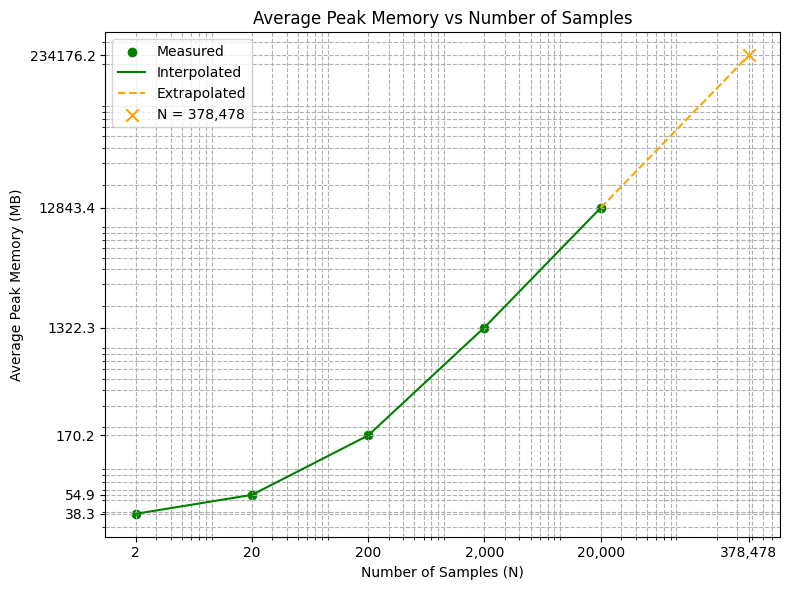

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def plot_memory(Ns, memory, N_extrap=378478):
    Ns = np.asarray(Ns, dtype=float)
    memory = np.asarray(memory, dtype=float)

    order = np.argsort(Ns)
    Ns = Ns[order]
    memory = memory[order]

    logN = np.log10(Ns)
    logM = np.log10(memory)

    f_log = interp1d(
        logN,
        logM,
        kind="linear",          
        fill_value="extrapolate"
    )

    logN_last = logN[-1]
    logN_extrap = np.log10(N_extrap)
    logN_solid = np.linspace(logN[0], logN_last, 300)
    logM_solid = f_log(logN_solid)
    Ns_solid = 10 ** logN_solid
    memory_solid = 10 ** logM_solid


    logN_dash = np.linspace(logN_last, logN_extrap, 100)
    logM_dash = f_log(logN_dash)
    Ns_dash = 10 ** logN_dash
    memory_dash = 10 ** logM_dash

    M_extrap = memory_dash[-1]
    
    plt.figure(figsize=(8, 6))
    plt.scatter(Ns, memory, color='green', marker='o', label='Measured')

    plt.plot(Ns_solid, memory_solid, color='green', linestyle='-', label='Interpolated')
    plt.plot(Ns_dash, memory_dash, color='orange', linestyle='--', label='Extrapolated')

    plt.scatter([N_extrap], [M_extrap], color='orange', marker='x', s=80,
                label=f'N = {N_extrap:,}')

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Number of Samples (N)')
    plt.ylabel('Average Peak Memory (MB)')
    plt.title('Average Peak Memory vs Number of Samples')
    plt.grid(True, which="both", ls="--")
    xticks = list(Ns) + [N_extrap]
    plt.xticks(xticks, [f"{int(x):,}" for x in xticks])
    yticks = list(memory) + [M_extrap]
    plt.yticks(yticks, [f"{m:.1f}" for m in yticks])
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_memory(Ns, memory, N_extrap=378478)